In [ ]:
# 1: Import
import sys
sys.path.append('../ml_pipeline')
from model_training import *

print(" Model training module loaded")

 Model training module loaded


In [2]:
# 2: Run preparation pipeline
input_path = '../data/processed/insurance_claims_engineered.csv'
output_dir = '../data/processed/'

metadata = prepare_training_data(
    input_path=input_path,
    output_dir=output_dir,
    sampling_method='smote',
    sampling_strategy=0.5,  # 50:50 balance
    random_state=42
)

PREPARING DATA FOR MODEL TRAINING
 Loaded engineered data
Features: 76
Samples: 15,420
Fraud cases: 923 (5.99%)

=== SPLITTING DATA ===

Dataset Split:
  Training:   10,794 samples (70.0%)
  Validation: 2,313 samples (15.0%)
  Test:       2,313 samples (15.0%)

Fraud Distribution:
  Training:   646 frauds (5.98%)
  Validation: 139 frauds (6.01%)
  Test:       138 frauds (5.97%)

=== HANDLING CLASS IMBALANCE ===

Before balancing:
  Legitimate: 10,148
  Fraud: 646
  Ratio: 1:15
  Imbalance: 93.6% skew

✓ Applied SMOTE (Synthetic Minority Over-sampling)

After balancing:
  Legitimate: 10,148
  Fraud: 5,074
  Ratio: 1:2.0
  Balance: 50.0% fraud / 50.0% legitimate
  Total samples: 15,222 (from 10,794)

=== VERIFICATION ===

Shapes:
  X_train: (15222, 76)
  X_val: (2313, 76)
  X_test: (2313, 76)

 No data leakage - train/val/test split before SMOTE guarantees independence

Fraud distribution consistency:
  Training:   33.33%
  Validation: 6.01%
  Test:       5.97%

Null values:
  X_train: 0

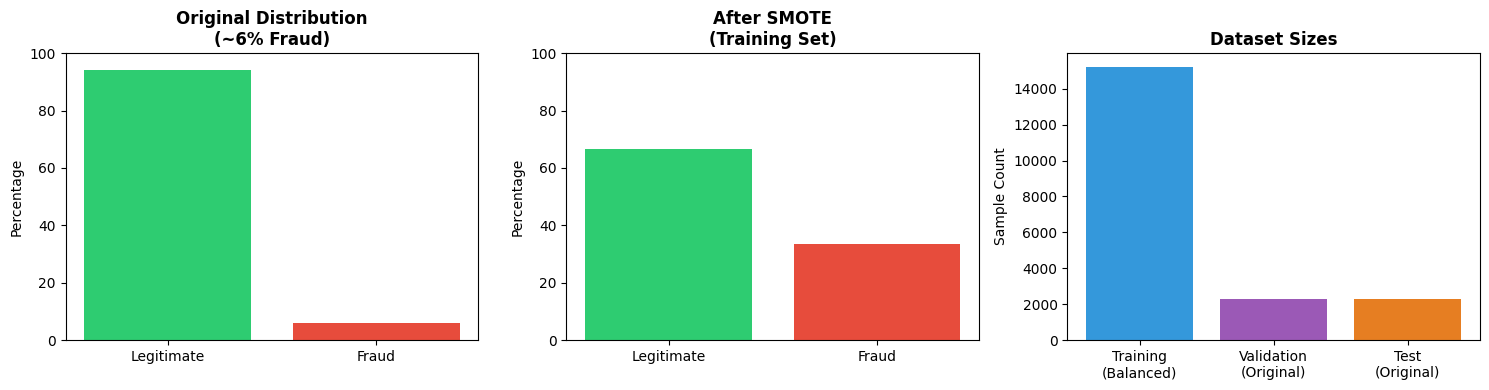

In [3]:
# 3: Visualize class balance
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before SMOTE
y = metadata['y_val']  # Use validation (unbalanced) as proxy for original
axes[0].bar(['Legitimate', 'Fraud'], 
            [(1-y.mean())*100, y.mean()*100],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Original Distribution\n(~6% Fraud)', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_ylim([0, 100])

# After SMOTE (Training)
y_train = metadata['y_train']
axes[1].bar(['Legitimate', 'Fraud'],
            [(1-y_train.mean())*100, y_train.mean()*100],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE\n(Training Set)', fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_ylim([0, 100])

# Sample counts
sets = ['Training\n(Balanced)', 'Validation\n(Original)', 'Test\n(Original)']
counts = [metadata['train_samples'], metadata['val_samples'], metadata['test_samples']]
axes[2].bar(sets, counts, color=['#3498db', '#9b59b6', '#e67e22'])
axes[2].set_title('Dataset Sizes', fontweight='bold')
axes[2].set_ylabel('Sample Count')

plt.tight_layout()
plt.savefig('../data/processed/data_split_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# 4: Inspect split datasets
train_df = pd.read_csv('../data/processed/train_balanced.csv')
val_df = pd.read_csv('../data/processed/validation.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print("=== DATASET INSPECTION ===\n")
print(f"Training (Balanced):")
print(f"  Shape: {train_df.shape}")
print(f"  Fraud rate: {train_df['FraudFound_P'].mean()*100:.2f}%")
print(f"  Fraud count: {train_df['FraudFound_P'].sum():,}")

print(f"\nValidation (Original ratio):")
print(f"  Shape: {val_df.shape}")
print(f"  Fraud rate: {val_df['FraudFound_P'].mean()*100:.2f}%")
print(f"  Fraud count: {val_df['FraudFound_P'].sum():,}")

print(f"\nTest (Original ratio):")
print(f"  Shape: {test_df.shape}")
print(f"  Fraud rate: {test_df['FraudFound_P'].mean()*100:.2f}%")
print(f"  Fraud count: {test_df['FraudFound_P'].sum():,}")

=== DATASET INSPECTION ===

Training (Balanced):
  Shape: (15222, 77)
  Fraud rate: 33.33%
  Fraud count: 5,074

Validation (Original ratio):
  Shape: (2313, 77)
  Fraud rate: 6.01%
  Fraud count: 139

Test (Original ratio):
  Shape: (2313, 77)
  Fraud rate: 5.97%
  Fraud count: 138


In [ ]:
# 5: Verify no data leakage
print("=== CHECKING FOR DATA LEAKAGE ===\n")

# Check if any samples appear in multiple sets
train_hashes = set(pd.util.hash_pandas_object(train_df.drop('FraudFound_P', axis=1)))
val_hashes = set(pd.util.hash_pandas_object(val_df.drop('FraudFound_P', axis=1)))
test_hashes = set(pd.util.hash_pandas_object(test_df.drop('FraudFound_P', axis=1)))

overlap_train_val = len(train_hashes & val_hashes)
overlap_train_test = len(train_hashes & test_hashes)
overlap_val_test = len(val_hashes & test_hashes)

print(f"Train-Val overlap: {overlap_train_val} samples")
print(f"Train-Test overlap: {overlap_train_test} samples")
print(f"Val-Test overlap: {overlap_val_test} samples")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print("\n✅ No data leakage detected!")
else:
    print("\n⚠️ Warning: Potential data leakage detected!")

=== CHECKING FOR DATA LEAKAGE ===

Train-Val overlap: 0 samples
Train-Test overlap: 0 samples
Val-Test overlap: 0 samples

✅ No data leakage detected!
